In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

filename = 'Attack_Dataset.csv'
data = pd.read_csv(filename, encoding='latin1')
data.head()

,ID,Title,Category,Attack Type,Scenario Description,Tools Used,Attack Steps,Target Type,Vulnerability,MITRE Technique,Impact,Detection Method,Solution,Tags,Source,Unnamed: 15
0,1,Authentication Bypass via SQL Injection,Mobile Security,SQL Injection (SQLi),A login form fails to validate or sanitize inp...,"Browser, Burp Suite, SQLMap",1. Reconnaissance: Find a login form on the we...,"Web Login Portals (e.g., banking, admin dashbo...",Unsanitized input fields in SQL queries,"T1078 (Valid Accounts), T1190 (Exploit Public-...","Full account takeover, data theft, privilege e...","Web server logs, anomaly detection (e.g., logi...","Use prepared statements, Sanitize inputs, Limi...","SQLi, Authentication Bypass, Web Security, OWA...","OWASP, MITRE ATT&CK, DVWA",NaN
1,2,Union-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,This attack occurs when a hacker uses the SQL ...,"SQLMap, Burp Suite, Havij, Browser Developer T...",1. Identify User Input Points: Attacker finds ...,"Web Applications, Login Pages, Search Forms",Improperly filtered input fields that allow SQ...,T1190 â Exploit Public-Facing Application,"Data leakage, Credential theft, Account takeov...",Web Application Firewalls (WAF)Log AnalysisInp...,Use parameterized queries (Prepared Statements...,#SQLInjection #WebSecurity #UnionAttack #OWASP...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",NaN
2,3,Error-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,This attack occurs when an attacker intentiona...,"SQLMap, Burp Suite, Manual Browser Testing, Havij",1. Identify Input Points:Attacker finds a fiel...,"Web Applications, Login Forms, URL Parameters,...",Error message exposure due to lack of input va...,T1190 â Exploit Public-Facing Application,"Information disclosure, Database structure exp...",Review and monitor error logsEnable generic er...,Turn off detailed error messages in production...,#SQLInjection #ErrorLeakage #WebAppSecurity #O...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",NaN
3,4,Blind SQL Injection,AI Agents & LLM Exploits,SQL Injection,"In Blind SQL Injection, the attacker doesnât...","SQLMap, Burp Suite, sqlninja, Manual Browser T...",1. Find a User Input Point:Attacker finds a pl...,"Web Applications, Login Pages, Search Fields, ...","No error messages, but user input is still pas...",T1190 â Exploit Public-Facing Application,Slow and stealthy data theftFull database comp...,Monitor for slow and repetitive requestsAnalyz...,Use parameterized queries (prepared statements...,#BlindSQLi #TimeBasedSQLi #WebAppSecurity #OWA...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger, SQ...",NaN
4,5,Second-Order SQL Injection,AI Agents & LLM Exploits,SQL Injection,"In a Second-Order SQL Injection, the attacker ...","Burp Suite, SQLMap, Postman, Browser Dev Tools...",1. Identify Stored Input Fields:The attacker l...,"Web Applications, User Registration Forms, Pro...",Trusting previously stored unvalidated data in...,T1505.003 â SQL Injection,Delayed data theftUnexpected system behaviorSe...,Log monitoring for delayed query failuresTrack...,Sanitize and validate inputs both at entry and...,#SecondOrderSQLi #DelayedInjection #StoredInje...,"OWASP, MITRE ATT&CK, PortSwigger Academy, Acun...",NaN


In [35]:
data.iloc[3, 4]

'In Blind SQL Injection, the attacker doesnâ\x80\x99t see error messages or data output directly, but can still extract data by sending specific questions to the database and observing the applicationâ\x80\x99s behavior (like page load times or content changes).'

In [36]:
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12,6)

In [37]:
print("Dataset Shape: ", data.shape)
print("\n")
print("\nDataset Info\n")
data.info()


Dataset Shape:  (14133, 16)



Dataset Info

<class 'pandas.DataFrame'>
RangeIndex: 14133 entries, 0 to 14132
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ID                    14133 non-null  int64
 1   Title                 14133 non-null  str  
 2   Category              14133 non-null  str  
 3   Attack Type           14133 non-null  str  
 4   Scenario Description  14133 non-null  str  
 5   Tools Used            14119 non-null  str  
 6   Attack Steps          14133 non-null  str  
 7   Target Type           14129 non-null  str  
 8   Vulnerability         14115 non-null  str  
 9   MITRE Technique       14109 non-null  str  
 10  Impact                14130 non-null  str  
 11  Detection Method      14129 non-null  str  
 12  Solution              14130 non-null  str  
 13  Tags                  14130 non-null  str  
 14  Source                13973 non-null  str  
 15  Unnamed: 15        

ID                          0
Title                       0
Category                    0
Attack Type                 0
Scenario Description        0
Tools Used                 14
Attack Steps                0
Target Type                 4
Vulnerability              18
MITRE Technique            24
Impact                      3
Detection Method            4
Solution                    3
Tags                        3
Source                    160
Unnamed: 15             14087
dtype: int64


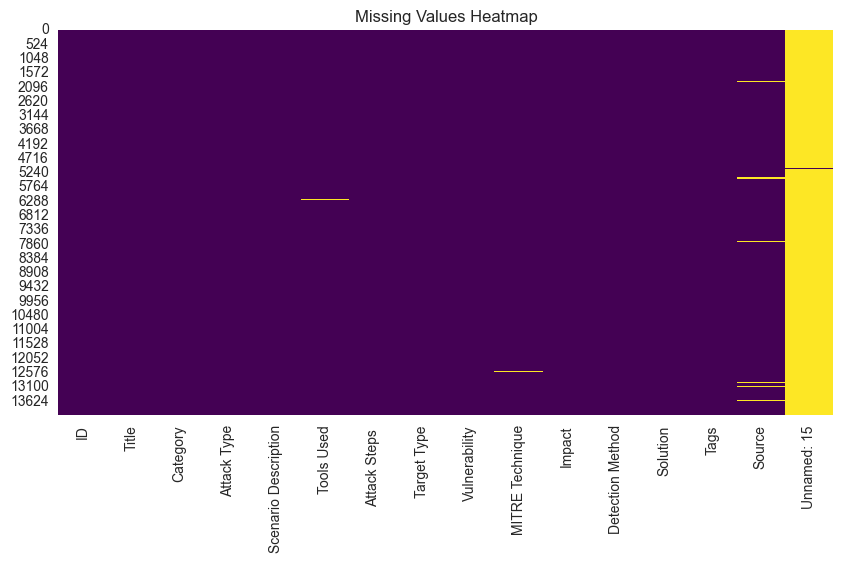

In [38]:
missing_val_count = data.isnull().sum()
print(missing_val_count)
plt.figure(figsize=(10,5))
sns.heatmap(data.isnull(), cbar = False, cmap = 'viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [39]:
duplicates = data.duplicated().sum()
print("Number of Duplicate rows: ", duplicates)

Number of Duplicate rows:  0


In [40]:
data = data.drop('Unnamed: 15', axis=1)

print("New dataset shape:", data.shape)
print("\nNew missing vals:")
print(data.isnull().sum())

New dataset shape: (14133, 15)

New missing vals:
ID                        0
Title                     0
Category                  0
Attack Type               0
Scenario Description      0
Tools Used               14
Attack Steps              0
Target Type               4
Vulnerability            18
MITRE Technique          24
Impact                    3
Detection Method          4
Solution                  3
Tags                      3
Source                  160
dtype: int64


In [41]:
missing_val_cols = [
    "Tools Used",
    "Target Type",
    "Vulnerability",
    "MITRE Technique",
    "Impact",
    "Detection Method",
    "Solution",
    "Tags",
]

data[missing_val_cols] = data[missing_val_cols].fillna("Not Specified")
data["Source"] = data["Source"].fillna("Unknown")

print("Remaining missing vals\n\n")
print(data.isnull().sum())

Remaining missing vals


ID                      0
Title                   0
Category                0
Attack Type             0
Scenario Description    0
Tools Used              0
Attack Steps            0
Target Type             0
Vulnerability           0
MITRE Technique         0
Impact                  0
Detection Method        0
Solution                0
Tags                    0
Source                  0
dtype: int64


In [42]:
data["missing_mitre"] = data["MITRE Technique"] == "Not Specified"
print("Rows with missing MITRE: ", data["missing_mitre"].sum())

Rows with missing MITRE:  24


In [43]:
# To fix mojibake encoding artifacts such as 'doesnâ\x80\x99t' in strings.
import re
import ftfy

text_cols = data.select_dtypes(include="object").columns

for c in text_cols:
    data[c] = data[c].astype(str).apply(ftfy.fix_text)



C:\Users\keert\AppData\Local\Temp\ipykernel_1292\2834338291.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = data.select_dtypes(include="object").columns


In [44]:
data["MITRE Technique"].iloc[1]

'T1190 – Exploit Public-Facing Application'

In [45]:
data["Attack Type"].value_counts()

Attack Type
Hardware Interface Exploitation    161
Wireless Attacks (Advanced)         95
Dependency Confusion                91
Fuzzer Configuration                75
Malicious Libraries                 74
                                  ... 
Supply Chain Simulation              1
Compliance Simulation                1
RF Interference Simulation           1
Filesystem Fault Simulation          1
Constellation Relay Spoofing         1
Name: count, Length: 8834, dtype: int64

In [46]:
categorical_cols = [
    "Category", 
    "Attack Type", 
    "Target Type", 
    "MITRE Technique", 
    "Tags"]

for c in categorical_cols:
    data[c] = (
        data[c]
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", " ", regex=True) # collapses multiple spaces
    ) 


In [47]:
data["Attack Type"].value_counts()

Attack Type
hardware interface exploitation    161
wireless attacks (advanced)         95
dependency confusion                91
fuzzer configuration                75
malicious libraries                 74
                                  ... 
supply chain simulation              1
compliance simulation                1
rf interference simulation           1
filesystem fault simulation          1
constellation relay spoofing         1
Name: count, Length: 8829, dtype: int64

In [48]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text)          # collapse whitespace
    text = re.sub(r"[^\x00-\x7F]+", " ", text) # remove remaining non-ASCII
    text = text.strip()
    return text

semantic_cols = [col for col in data.columns if col not in 
                 ["ID", "Title", "Category", "Attack Type", "Target Type", 
                  "MITRE Technique", "Tags", "Source", "mitre_was_missing"]]
for col in semantic_cols:
    data[col] =data[col].apply(clean_text)

In [49]:
data.head()

,ID,Title,Category,Attack Type,Scenario Description,Tools Used,Attack Steps,Target Type,Vulnerability,MITRE Technique,Impact,Detection Method,Solution,Tags,Source,missing_mitre
0,1,Authentication Bypass via SQL Injection,mobile security,sql injection (sqli),A login form fails to validate or sanitize inp...,"Browser, Burp Suite, SQLMap",1. Reconnaissance: Find a login form on the we...,"web login portals (e.g., banking, admin dashbo...",Unsanitized input fields in SQL queries,"t1078 (valid accounts), t1190 (exploit public-...","Full account takeover, data theft, privilege e...","Web server logs, anomaly detection (e.g., logi...","Use prepared statements, Sanitize inputs, Limi...","sqli, authentication bypass, web security, owa...","OWASP, MITRE ATT&CK, DVWA",False
1,2,Union-Based SQL Injection,ai agents & llm exploits,sql injection,This attack occurs when a hacker uses the SQL ...,"SQLMap, Burp Suite, Havij, Browser Developer T...",1. Identify User Input Points: Attacker finds ...,"web applications, login pages, search forms",Improperly filtered input fields that allow SQ...,t1190 – exploit public-facing application,"Data leakage, Credential theft, Account takeov...",Web Application Firewalls (WAF)Log AnalysisInp...,Use parameterized queries (Prepared Statements...,#sqlinjection #websecurity #unionattack #owasp...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",False
2,3,Error-Based SQL Injection,ai agents & llm exploits,sql injection,This attack occurs when an attacker intentiona...,"SQLMap, Burp Suite, Manual Browser Testing, Havij",1. Identify Input Points:Attacker finds a fiel...,"web applications, login forms, url parameters,...",Error message exposure due to lack of input va...,t1190 – exploit public-facing application,"Information disclosure, Database structure exp...",Review and monitor error logsEnable generic er...,Turn off detailed error messages in production...,#sqlinjection #errorleakage #webappsecurity #o...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",False
3,4,Blind SQL Injection,ai agents & llm exploits,sql injection,"In Blind SQL Injection, the attacker doesn't s...","SQLMap, Burp Suite, sqlninja, Manual Browser T...",1. Find a User Input Point:Attacker finds a pl...,"web applications, login pages, search fields, ...","No error messages, but user input is still pas...",t1190 – exploit public-facing application,Slow and stealthy data theftFull database comp...,Monitor for slow and repetitive requestsAnalyz...,Use parameterized queries (prepared statements...,#blindsqli #timebasedsqli #webappsecurity #owa...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger, SQ...",False
4,5,Second-Order SQL Injection,ai agents & llm exploits,sql injection,"In a Second-Order SQL Injection, the attacker ...","Burp Suite, SQLMap, Postman, Browser Dev Tools...",1. Identify Stored Input Fields:The attacker l...,"web applications, user registration forms, pro...",Trusting previously stored unvalidated data in...,t1505.003 – sql injection,Delayed data theftUnexpected system behaviorSe...,Log monitoring for delayed query failuresTrack...,Sanitize and validate inputs both at entry and...,#secondordersqli #delayedinjection #storedinje...,"OWASP, MITRE ATT&CK, PortSwigger Academy, Acun...",False


In [50]:
data.to_csv("attack_ds_cleaned.csv", index=False)
print("saved")


saved


In [51]:
# import requests, numpy as np
# from sklearn.cluster import KMeans
# from sklearn.preprocessing import normalize
# from collections import Counter

# OLLAMA_URL = "http://localhost:11434/api/embeddings"
# MODEL = "qllama/bge-m3:q4_k_m"

# def get_embeddings(text):
#     response = requests.post(OLLAMA_URL, json={
#         "model": MODEL,
#         "prompt": text
#     })
#     return np.array(response.json()["embedding"])

# def embed_all(values):
#     embeddings = []
#     for i, val in enumerate(values):
#         if i % 50 == 0:
#             print(f"Embedding {i}/{len(values)} ... ")
#         embeddings.append(get_embeddings(str(val)))
#     return np.array(embeddings)

# def cluster_column(series, n_clusters = 15):
#     unique = series.dropna().unique().tolist()
#     print(f"Embedding {len(unique)} unique values...")
#     embeddings = embed_all(unique)
#     embeddings_norm = normalize(embeddings)

#     print(f"Clustering into {n_clusters} groups...")
#     kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
#     labels = kmeans.fit_predict(embeddings_norm)

#     cluster_names = {}
#     for cluster_id in range(n_clusters):
#         members = [unique[i] for i, l in enumerate(labels) if l == cluster_id]

#         cluster_names[cluster_id] = f"Group: {min(members, key=len)}"

#     val_cluster = {val:cluster_names[labels[i]] for i, val in enumerate(unique)}
#     return series.map(val_cluster).fillna("Other")



In [52]:
# data["Attack Type Group"] = cluster_column(data["Attack Type"], n_clusters=15)
# data["Category Group"] = cluster_column(data["Category"], n_clusters=12)
# data["Target Type Group"] = cluster_column(data["Target Type"], n_clusters=10)

# for col in ["Attack Type Group", "Category Group", "Target Type Group"]:
#     print(f"\n{col}: \n{data[col].value_counts()}\n")

# data.head()

In [ ]:
import pandas as pd
import requests
import numpy as np
import json
import os
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

OLLAMA_URL = "http://localhost:11434/api/embed"  
EMBED_MODEL = "qllama/bge-m3:q4_k_m"
CACHE_FILE = "embeddings_cache.json"       

def get_embeddings_batch(texts: list) -> list:
    response = requests.post(OLLAMA_URL, json={
        "model": EMBED_MODEL,
        "input": texts        # list input = batch mode
    })
    return response.json()["embeddings"]

def embed_all_cached(values: list, batch_size: int = 50) -> np.ndarray:
    # Load existing cache if available
    if os.path.exists(CACHE_FILE):
        with open(CACHE_FILE, "r") as f:
            cache = json.load(f)
        print(f"Loaded {len(cache)} cached embeddings")
    else:
        cache = {}

    to_embed = [v for v in values if str(v) not in cache]
    print(f"Already cached: {len(cache)}, Still need: {len(to_embed)}")

    for i in range(0, len(to_embed), batch_size):
        batch = [str(v) for v in to_embed[i:i + batch_size]]
        print(f"  Batch {i}–{i+len(batch)} of {len(to_embed)}...", end=" ")
        
        try:
            embeddings = get_embeddings_batch(batch)
            for text, emb in zip(batch, embeddings):
                cache[text] = emb
            print("✓")
        except Exception as e:
            print(f"✗ {e}")

        # Save cache every batch — safe to interrupt anytime
        if i % 200 == 0:
            with open(CACHE_FILE, "w") as f:
                json.dump(cache, f)

    with open(CACHE_FILE, "w") as f:
        json.dump(cache, f)

    return np.array([cache[str(v)] for v in values])


def cluster_column(series: pd.Series, n_clusters: int = 15) -> pd.Series:
    unique_vals = series.dropna().unique().tolist()
    
    embeddings = embed_all_cached(unique_vals)
    embeddings_norm = normalize(embeddings)
    
    print(f"Clustering {len(unique_vals)} values into {n_clusters} groups...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embeddings_norm)
    
    cluster_names = {}
    for cluster_id in range(n_clusters):
        members = [unique_vals[i] for i, l in enumerate(labels) if l == cluster_id]
        cluster_names[cluster_id] = f"Group: {min(members, key=len)}"
    
    val_to_cluster = {val: cluster_names[labels[i]] for i, val in enumerate(unique_vals)}
    return series.map(val_to_cluster).fillna("Other")




In [54]:
data["Attack Type Group"] = cluster_column(data["Attack Type"], n_clusters=15)
data["Category Group"]    = cluster_column(data["Category"],    n_clusters=12)
data["Target Type Group"] = cluster_column(data["Target Type"], n_clusters=10)

data.to_csv("cybersecurity_grouped.csv", index=False)

Already cached: 0, Still need: 8829
  Batch 0–50 of 8829... ✓
  Batch 50–100 of 8829... ✓
  Batch 100–150 of 8829... ✓
  Batch 150–200 of 8829... ✓
  Batch 200–250 of 8829... ✓
  Batch 250–300 of 8829... ✓
  Batch 300–350 of 8829... ✓
  Batch 350–400 of 8829... ✓
  Batch 400–450 of 8829... ✓
  Batch 450–500 of 8829... ✓
  Batch 500–550 of 8829... ✓
  Batch 550–600 of 8829... ✓
  Batch 600–650 of 8829... ✓
  Batch 650–700 of 8829... ✓
  Batch 700–750 of 8829... ✓
  Batch 750–800 of 8829... ✓
  Batch 800–850 of 8829... ✓
  Batch 850–900 of 8829... ✓
  Batch 900–950 of 8829... ✓
  Batch 950–1000 of 8829... ✓
  Batch 1000–1050 of 8829... ✓
  Batch 1050–1100 of 8829... ✓
  Batch 1100–1150 of 8829... ✓
  Batch 1150–1200 of 8829... ✓
  Batch 1200–1250 of 8829... ✓
  Batch 1250–1300 of 8829... ✓
  Batch 1300–1350 of 8829... ✓
  Batch 1350–1400 of 8829... ✓
  Batch 1400–1450 of 8829... ✓
  Batch 1450–1500 of 8829... ✓
  Batch 1500–1550 of 8829... ✓
  Batch 1550–1600 of 8829... ✓
  Batch 1600–16

In [ ]:
data.head()

,ID,Title,Category,Attack Type,Scenario Description,Tools Used,Attack Steps,Target Type,Vulnerability,MITRE Technique,Impact,Detection Method,Solution,Tags,Source,missing_mitre,Attack Type Group,Category Group,Target Type Group
0,1,Authentication Bypass via SQL Injection,mobile security,sql injection (sqli),A login form fails to validate or sanitize inp...,"Browser, Burp Suite, SQLMap",1. Reconnaissance: Find a login form on the we...,"web login portals (e.g., banking, admin dashbo...",Unsanitized input fields in SQL queries,"t1078 (valid accounts), t1190 (exploit public-...","Full account takeover, data theft, privilege e...","Web server logs, anomaly detection (e.g., logi...","Use prepared statements, Sanitize inputs, Limi...","sqli, authentication bypass, web security, owa...","OWASP, MITRE ATT&CK, DVWA",False,Group: injection,Group: ai/ml security,Group: web
1,2,Union-Based SQL Injection,ai agents & llm exploits,sql injection,This attack occurs when a hacker uses the SQL ...,"SQLMap, Burp Suite, Havij, Browser Developer T...",1. Identify User Input Points: Attacker finds ...,"web applications, login pages, search forms",Improperly filtered input fields that allow SQ...,t1190 – exploit public-facing application,"Data leakage, Credential theft, Account takeov...",Web Application Firewalls (WAF)Log AnalysisInp...,Use parameterized queries (Prepared Statements...,#sqlinjection #websecurity #unionattack #owasp...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",False,Group: injection,Group: ai agents & llm exploits,Group: web
2,3,Error-Based SQL Injection,ai agents & llm exploits,sql injection,This attack occurs when an attacker intentiona...,"SQLMap, Burp Suite, Manual Browser Testing, Havij",1. Identify Input Points:Attacker finds a fiel...,"web applications, login forms, url parameters,...",Error message exposure due to lack of input va...,t1190 – exploit public-facing application,"Information disclosure, Database structure exp...",Review and monitor error logsEnable generic er...,Turn off detailed error messages in production...,#sqlinjection #errorleakage #webappsecurity #o...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",False,Group: injection,Group: ai agents & llm exploits,Group: web
3,4,Blind SQL Injection,ai agents & llm exploits,sql injection,"In Blind SQL Injection, the attacker doesn't s...","SQLMap, Burp Suite, sqlninja, Manual Browser T...",1. Find a User Input Point:Attacker finds a pl...,"web applications, login pages, search fields, ...","No error messages, but user input is still pas...",t1190 – exploit public-facing application,Slow and stealthy data theftFull database comp...,Monitor for slow and repetitive requestsAnalyz...,Use parameterized queries (prepared statements...,#blindsqli #timebasedsqli #webappsecurity #owa...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger, SQ...",False,Group: injection,Group: ai agents & llm exploits,Group: web
4,5,Second-Order SQL Injection,ai agents & llm exploits,sql injection,"In a Second-Order SQL Injection, the attacker ...","Burp Suite, SQLMap, Postman, Browser Dev Tools...",1. Identify Stored Input Fields:The attacker l...,"web applications, user registration forms, pro...",Trusting previously stored unvalidated data in...,t1505.003 – sql injection,Delayed data theftUnexpected system behaviorSe...,Log monitoring for delayed query failuresTrack...,Sanitize and validate inputs both at entry and...,#secondordersqli #delayedinjection #storedinje...,"OWASP, MITRE ATT&CK, PortSwigger Academy, Acun...",False,Group: injection,Group: ai agents & llm exploits,Group: web


: 

In [ ]:
data["Attack Type Group"].value_counts()